<div class="alert alert-block alert-success" style="font-family: Times New Roman">
    <h4><strong>Laboratory Task 4</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
    <b>Instruction:</b> Train a linear regression model in PyTorch using a regression dataset.
    Use the following parameters.
</p>

<ul style="font-family:Times New Roman; font-size:15px">
    <li>Criterion: MSE Loss</li>
    <li>Fully Connected Layers x 2</li>
    <li>Batch Size: 8</li>
    <li>Optimizer: SGD</li>
    <li>Epoch: 1000</li>
</ul>
</div>

## Dataset

This uses the **Diabetes dataset** from `sklearn.datasets` — a standard, built-in regression
dataset with 10 numeric input features (age, BMI, blood pressure, etc.) and a continuous target
(a quantitative measure of disease progression). It's a common choice for regression demos since
it's small, real, and doesn't require downloading anything.

## Model

Since the task calls for **2 fully connected layers**, the model is a small feed-forward network:

$$\text{Input (10 features)} \rightarrow \text{Linear} \rightarrow \text{ReLU} \rightarrow \text{Linear} \rightarrow \text{Output (1 value)}$$

A ReLU activation sits between the two layers so they aren't mathematically equivalent to a
single linear layer — otherwise stacking two linear layers with nothing in between would just
collapse into one linear transform.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [2]:
# --- Load the regression dataset ---
data = load_diabetes()
X, y = data.data, data.target.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (442, 10)
y shape: (442, 1)


## Preprocessing

Split into train/test sets, then standardize (zero mean, unit variance) both the features and
the target. Standardizing the target matters here too — SGD with a small learning rate converges
much more reliably on a scaled target than on the raw values (which range roughly 25–346).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print("Train size:", X_train_t.shape[0], " Test size:", X_test_t.shape[0])

Train size: 353  Test size: 89


In [4]:
# --- DataLoader with batch size 8 ---
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

print("Number of batches per epoch:", len(train_loader))

Number of batches per epoch: 45


## Model Definition

In [5]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=16):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = LinearRegressionModel(input_dim=X_train_t.shape[1])
print(model)

LinearRegressionModel(
  (fc1): Linear(in_features=10, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


## Loss Function & Optimizer

In [6]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## Training Loop (1000 Epochs)

In [7]:
epochs = 1000
loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)

    epoch_loss /= len(train_dataset)
    loss_history.append(epoch_loss)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f}")

Epoch [100/1000] - Loss: 0.4000


Epoch [200/1000] - Loss: 0.3400


Epoch [300/1000] - Loss: 0.2959


Epoch [400/1000] - Loss: 0.2837


Epoch [500/1000] - Loss: 0.2699


Epoch [600/1000] - Loss: 0.2548


Epoch [700/1000] - Loss: 0.2371


Epoch [800/1000] - Loss: 0.2264


Epoch [900/1000] - Loss: 0.2257


Epoch [1000/1000] - Loss: 0.2661


## Training Loss Curve

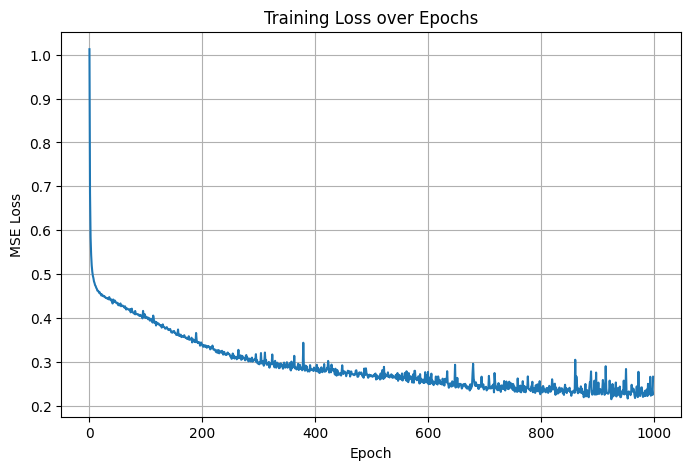

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()

## Evaluation on Test Set

In [9]:
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_t)
    test_loss = criterion(test_predictions, y_test_t)

print(f"Test MSE Loss (scaled target): {test_loss.item():.4f}")

# Convert predictions back to the original target scale for interpretability
test_predictions_original = y_scaler.inverse_transform(test_predictions.numpy())
y_test_original = y_scaler.inverse_transform(y_test_t.numpy())

mse_original = np.mean((test_predictions_original - y_test_original) ** 2)
rmse_original = np.sqrt(mse_original)
print(f"Test MSE (original scale):  {mse_original:.2f}")
print(f"Test RMSE (original scale): {rmse_original:.2f}")

Test MSE Loss (scaled target): 0.6049
Test MSE (original scale):  3675.69
Test RMSE (original scale): 60.63


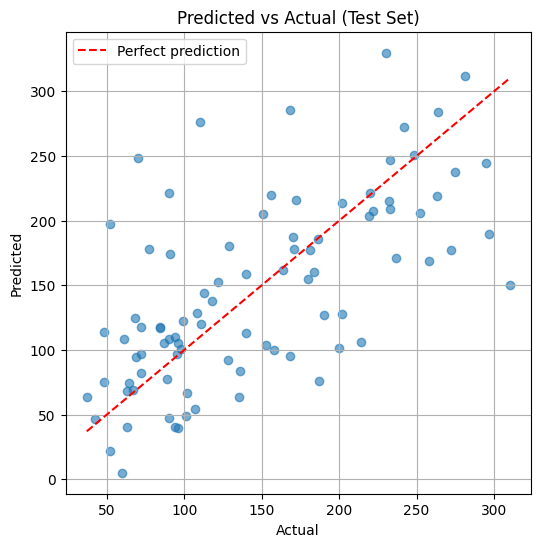

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_original, test_predictions_original, alpha=0.6)
plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    "r--", label="Perfect prediction"
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (Test Set)")
plt.legend()
plt.grid(True)
plt.show()

## Summary

- **Model:** 2 fully connected layers (10 → 16 hidden units → 1 output), with ReLU between them
- **Criterion:** MSE Loss
- **Optimizer:** SGD, learning rate 0.01
- **Batch size:** 8
- **Epochs:** 1000

The training loss curve above should decrease and flatten out over the 1000 epochs, and the
predicted-vs-actual scatter plot shows how closely the model's predictions track the true
disease-progression scores on unseen test data — points near the red dashed line are accurate
predictions.